In [9]:
import os, sys
sidm_path = str(os.getcwd()).split('/sidm')[0]
if sidm_path not in sys.path:
    sys.path.insert(1, sidm_path)
from sidm.tools import utilities, scaleout, sidm_processor, llpnanoaodschema
from sidm.studies.cosmicVeto import functions

import matplotlib.pyplot as plt
import mplhep as hep
utilities.set_plot_style()

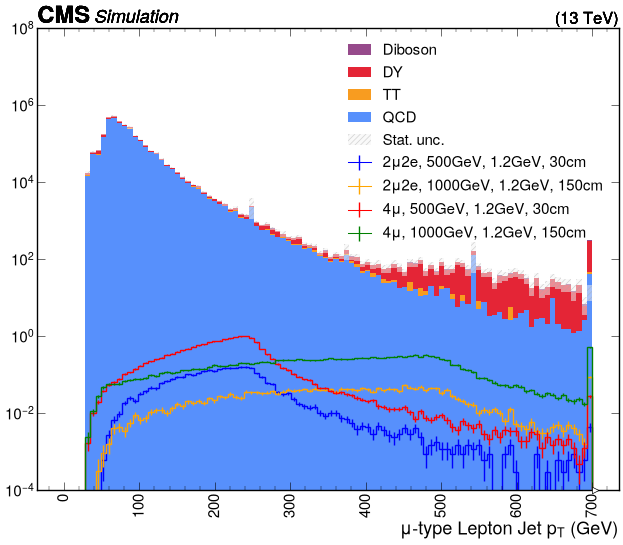

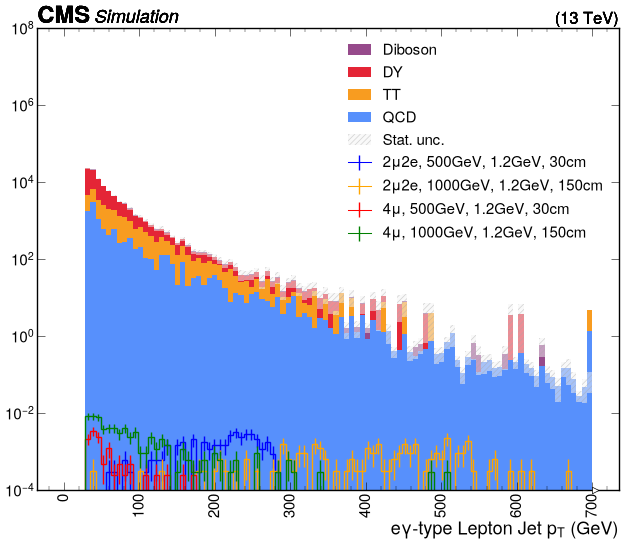

In [8]:

channel_name = 'cr_1egmOr1mu_lj_withoutEta_phi'
output_signal_2mu = functions.load_output("signal_2mu2e", channel_name)
output_signal_4mu = functions.load_output("signal_4mu", channel_name)
TT = functions.get_bg_file_names("TTJets")
DY = functions.get_bg_file_names("DYJetsToLL")
QCD = functions.get_bg_file_names("QCD")
DB = functions.get_bg_file_names("Diboson")
folder_name = f"OutputFiles/{channel_name}"
summed_QCD = utilities.sum_hist(QCD, folder_name)
summed_TT  = utilities.sum_hist(TT,  folder_name)
summed_DY  = utilities.sum_hist(DY, folder_name)
summed_DB  = utilities.sum_hist(DB,  folder_name)
summed_bg  = utilities.sum_hist(DB + QCD + TT + DY, folder_name)


S = [
    '2Mu2E_500GeV_1p2GeV_1p9mm',
    "2Mu2E_1000GeV_1p2GeV_4p8mm",
    
    '4Mu_500GeV_1p2GeV_1p9mm',
    '4Mu_1000GeV_1p2GeV_4p8mm'
    
]

histograms_list = ["mu_lj_pt",  "egm_lj_pt" ]
colors = ["blue", "orange", "red", "green", "purple"]

for i, histogram_name in enumerate(histograms_list):
    plt.figure(figsize=(15,12))
    sum_bg_qcd = summed_QCD[histogram_name][channel_name, :]
    sum_bg_tt = summed_TT[histogram_name][channel_name, :]
    sum_bg_dy = summed_DY[histogram_name][channel_name, :]
    sum_bg_db = summed_DB[histogram_name][channel_name, :]
    sum_bg_total = summed_bg[histogram_name][channel_name, :]
    utilities.plot([sum_bg_qcd, sum_bg_tt, sum_bg_dy, sum_bg_db],
    histtype="fill",
    label=["QCD", "TT",r"DY", "Diboson"],stack=True,
    )
    hep.histplot(sum_bg_total, histtype="band", yerr=True, color="gray",hatch="///",
                label="Stat. unc.")
    for j,s in enumerate(S):
        label = functions.get_signal_label(s)
        if label[0]=="2":
            histogram= output_signal_2mu["out"][s]["hists"][histogram_name][channel_name, :]
        elif label[0] == "4":
            histogram= output_signal_4mu["out"][s]["hists"][histogram_name][channel_name, :]
        else:
            print(f"output not found for{s}")
        utilities.plot(histogram, label=label, linewidth=2, color =colors[j])
   
    plt.legend()
    plt.yscale("log")
    plt.ylim(1e-4, 1e8)
    plt.xticks(rotation=90)
    plt.savefig(f"Plots/{channel_name}_{histogram_name}_signal_bg.png", dpi=150)
    plt.show()
    plt.close()